In [ ]:

#TASK 1
import pandas as pd
import numpy as np
#path
aqi_df  = pd.read_csv('/content/city_day.csv')
crop_df = pd.read_csv('/content/crop_production.csv')

print(" AQI HEAD")
print(aqi_df.head())

print("\nCROP HEAD")
print(crop_df.head())

# SHAPE
print("\n SHAPE")
print("AQI:", aqi_df.shape)
print("Crop:", crop_df.shape)

# COLUMNS
print("\nCOLUMNS ")
print(aqi_df.columns)
print(crop_df.columns)

# INFO
print("\n INFO ")
aqi_df.info()
crop_df.info()

# MISSING VALUES
print("\nMISSING VALUES")
print(aqi_df.isnull().sum())
print(crop_df.isnull().sum())

# DUPLICATES
print("\nDUPLICATES ")
print("AQI:", aqi_df.duplicated().sum())
print("Crop:", crop_df.duplicated().sum())

# SUMMARY
print("\n SUMMARY")
print(aqi_df.describe())

print(" \n\n#################")
print(crop_df.describe())

# DATE FIX
aqi_df['Date'] = pd.to_datetime(aqi_df['Date'], errors='coerce')

# YEAR RANGE
print("\nYEAR RANGE ")
print("AQI:", aqi_df['Date'].dt.year.min(), "to", aqi_df['Date'].dt.year.max())
print("Crop:", crop_df['Crop_Year'].min(), "to", crop_df['Crop_Year'].max())

 AQI HEAD
        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  

CROP HEAD
                    State_Name District_Name  Crop_Year       Season  \
0  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
1  Andaman and Nicobar I

### Data
- **head()** – to preview data → understood structure & sample values  
- **shape** – to check size → AQI smaller, crop larger dataset  
- **columns** – to view features → identified all variables  
- **info()** – to check data types & nulls → found wrong types & missing values  
- **isnull().sum()** – to count missing values → AQI has many nulls, crop has some  
- **duplicated().sum()** – to check duplicates → no duplicates found  
- **describe()** – statistical summary → understood range, mean, possible outliers  
- **nunique()** – unique values → dataset coverage (cities/states)  
- **to_datetime()** – convert date → enabled time analysis  
- **Year range check** → both datasets have similar time span  

###  Interpretation

- AQI dataset → many missing pollutant values  
- Crop dataset → missing production values  
- Data level mismatch (daily city vs yearly state)  
- Cleaning is required before analysis  

### What does a data scientist need to know about a dataset before using it? What functions help you find that?
A data scientist needs to know the size of the dataset , the data types of each column, how many missing values exist and where, whether duplicate records are present, and the basic statistical range of numerical columns to spot anything unrealistic. They also need to understand what each column represents before trusting it for modelling. Functions that help: df.shape, df.info(), df.describe(), df.isnull().sum(), df.duplicated().sum(), and df.head().

TASK **2**

In [ ]:

# TASK 2: MISSING VALUE HANDLING
import pandas as pd
import numpy as np

# Load datasets
aqi_df  = pd.read_csv('/content/city_day.csv')
crop_df = pd.read_csv('/content/crop_production.csv')

# BEFORE NULL COUNT
print("===== BEFORE TREATMENT =====")
print("\nAQI Missing Values:\n", aqi_df.isnull().sum())
print("\nCrop Missing Values:\n", crop_df.isnull().sum())

# Convert Date
aqi_df['Date'] = pd.to_datetime(aqi_df['Date'], errors='coerce')

# Drop columns with very high missing values (>50%)
threshold = len(aqi_df) * 0.5
aqi_df = aqi_df.dropna(axis=1, thresh=threshold)

# Fill numerical columns with median (robust to outliers)
num_cols = aqi_df.select_dtypes(include=np.number).columns
aqi_df[num_cols] = aqi_df[num_cols].fillna(aqi_df[num_cols].median())

# Fill categorical columns with mode
cat_cols = aqi_df.select_dtypes(include='object').columns
for col in cat_cols:
    aqi_df[col] = aqi_df[col].fillna(aqi_df[col].mode()[0])



# Filling production- median
crop_df['Production'] = crop_df['Production'].fillna(crop_df['Production'].median())

# ensure no missing in categorical
cat_cols_crop = crop_df.select_dtypes(include='object').columns
for col in cat_cols_crop:
    crop_df[col] = crop_df[col].fillna(crop_df[col].mode()[0])

# AFTER NULL COUNT
print("\n===== AFTER TREATMENT =====")
print("\nAQI Missing Values:\n", aqi_df.isnull().sum())
print("\nCrop Missing Values:\n", crop_df.isnull().sum())

# FINAL CHECK

print("\nRemaining Nulls in AQI:", aqi_df.isnull().sum().sum())
print("Remaining Nulls in Crop:", crop_df.isnull().sum().sum())

===== BEFORE TREATMENT =====

AQI Missing Values:
 City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Crop Missing Values:
 State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

===== AFTER TREATMENT =====

AQI Missing Values:
 City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64

Crop Missing Values:
 State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area

### Missing Value Handling

During inspection, both datasets contained missing values, but the extent and importance varied across columns. Therefore, a column-wise strategy was applied instead of using a single method for all.
####  AQI Dataset
* Columns with more than 50% missing values (e.g., Xylene) were dropped
  -These columns lack sufficient data and could introduce bias if imputed
* Remaining numerical columns were filled using median
  -Median is preferred over mean because AQI data may contain outliers, and median is more robust
* Categorical columnswere filled using mode
  -Preserves the most frequent category and maintains data consistency

#### Crop Dataset
* Production column had missing values
  -Filled using median instead of dropping rows to avoid loss of valuable data

###  Why Not Other Methods?

* Dropping all rows with nulls-would result in huge data loss, especially in AQI dataset
* Using mean for all columns - not suitable due to outliers, which can distort results
* Dropping important columns (like Production)- would remove critical information needed for analysis

###  Outcome
* Missing values were handled efficiently without losing important data
* Dataset is now clean, consistent, and reliable for further analysis
###  Final Insight
A selective approach was necessary because different columns have different importance and data patterns. This ensures better data quality and more accurate future analysis.


In [ ]:
#after fixinf all null values we checking how many null left

print("Total Remaining Nulls in AQI:", aqi_df.isnull().sum().sum())
print("Total Remaining Nulls in Crop:", crop_df.isnull().sum().sum())

Total Remaining Nulls in AQI: 0
Total Remaining Nulls in Crop: 0


### Null Check -After Treatment
- Used `isnull().sum().sum()` to calculate total remaining missing values in both datasets.

### Interpretation
- AQI Dataset-Total remaining null values = 0  
- Crop Dataset- Total remaining null values = 0  
Confirming that all missing values have been successfully handled.
### Conclusion
The datasets are now complete with no missing values.
Data is clean and ready for further analysis and model building.
Ensures no bias or errors will occur due to missing data.


###Does the volume of missing data matter? Does the column type matter? What does imputing with mean vs median assume about the data?
Yes, volume mattersbecause if a column is missing more than 40–50% of its values, imputing it introduces more assumption than fact, and dropping it is safer. Column type also matters — you cannot impute a categorical column with a mean; mode is used instead. For numerical columns, imputing with the mean assumes the data is normally distributed with no extreme values. Imputing with the median makes no such assumption and is safer when the data is skewed, because the median is not pulled by outliers the way the mean is.


In [ ]:
import pandas as pd

# files are in /content/ directly, NOT inside sample_data
aqi_df  = pd.read_csv('/content/city_day.csv')
crop_df = pd.read_csv('/content/crop_production.csv')

aqi_before = len(aqi_df)
crop_before = len(crop_df)

city_to_state = {
    'Ahmedabad': 'Gujarat', 'Aizawl': 'Mizoram', 'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab', 'Bengaluru': 'Karnataka', 'Bhopal': 'Madhya Pradesh',
    'Brajrajnagar': 'Odisha', 'Chandigarh': 'Chandigarh', 'Chennai': 'Tamil Nadu',
    'Coimbatore': 'Tamil Nadu', 'Delhi': 'Delhi', 'Ernakulam': 'Kerala',
    'Gurugram': 'Haryana', 'Guwahati': 'Assam', 'Hyderabad': 'Telangana',
    'Jaipur': 'Rajasthan', 'Jodhpur': 'Rajasthan', 'Kochi': 'Kerala',
    'Kolkata': 'West Bengal', 'Lucknow': 'Uttar Pradesh', 'Mumbai': 'Maharashtra',
    'Patna': 'Bihar', 'Shillong': 'Meghalaya', 'Talcher': 'Odisha',
    'Thiruvananthapuram': 'Kerala', 'Visakhapatnam': 'Andhra Pradesh'
}

# add State column to aqi_df since it only has City
aqi_df['State'] = aqi_df['City'].map(city_to_state)
aqi_df['City']  = aqi_df['City'].str.strip()
aqi_df['State'] = aqi_df['State'].str.strip()

# show error state names before fixing
print("error tate names in crop file:")
print([s for s in crop_df['State_Name'].unique() if s != s.strip()])

# strip trailing spaces from State_Name and Season
crop_df['State_Name'] = crop_df['State_Name'].str.strip()
crop_df['Season']     = crop_df['Season'].str.strip()

# rename State_Name to State so both files share the same merge key
crop_df.rename(columns={'State_Name': 'State'}, inplace=True)

# remove duplicates from both files
aqi_dups  = aqi_df.duplicated(subset=['City', 'Date']).sum()
crop_dups = crop_df.duplicated(subset=['State', 'District_Name', 'Crop', 'Crop_Year', 'Season']).sum()
aqi_df    = aqi_df.drop_duplicates(subset=['City', 'Date']).reset_index(drop=True)
crop_df   = crop_df.drop_duplicates(subset=['State', 'District_Name', 'Crop', 'Crop_Year', 'Season']).reset_index(drop=True)

# before vs after summary
print(f"\n{'File':<22} {'Before':>8} {'After':>8} {'Removed':>8}")
print(f"{'city_day.csv':<22} {aqi_before:>8,} {len(aqi_df):>8,} {aqi_before - len(aqi_df):>8,}")
print(f"{'crop_production.csv':<22} {crop_before:>8,} {len(crop_df):>8,} {crop_before - len(crop_df):>8,}")

# confirm which states will match when we merge in task 8
aqi_states  = set(aqi_df['State'].dropna().unique())
crop_states = set(crop_df['State'].dropna().unique())
print(f"\nMatching states     : {sorted(aqi_states & crop_states)}")
print(f"Only in AQI (Delhi) : {sorted(aqi_states - crop_states)}")
print(f"Only in Crop        : {sorted(crop_states - aqi_states)}")

error tate names in crop file:
['Jammu and Kashmir ', 'Telangana ']

File                     Before    After  Removed
city_day.csv             29,531   29,531        0
crop_production.csv     246,091  246,091        0

Matching states     : ['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Gujarat', 'Haryana', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']
Only in AQI (Delhi) : ['Delhi']
Only in Crop        : ['Andaman and Nicobar Islands', 'Arunachal Pradesh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Goa', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Manipur', 'Nagaland', 'Puducherry', 'Sikkim', 'Tripura', 'Uttarakhand']


## Task 3 — Output Interpretation

### Dirty State Names Found
- Jammu and Kashmir and Telangana  both had an invisible trailing space at the end
- After applying .str.strip() these are now clean — Jammu and Kashmirand Telangana
- Without this fix these two states would silently disappear from any merge with zero error or warning

### Before / After Table
- city_day.csv → 29,531 rows before and after → no duplicate City + Date combinations found
- crop_production.csv → 246,091 rows before and after → no duplicate records found
- Both files were already duplicate-free which is a good sign about data collection quality

### Matching States (19 states)
- 19 states exist in both files and will successfully join when we merge
- Think of it like a Venn diagram — only the overlapping middle part survives a merge
- These 19 states will form the base of all our analysis going forward

### Only in AQI — Delhi
- Delhi has air quality data but no crop production data
- This is not an error — Delhi is a Union Territory with no agricultural land
- It gets excluded from the merged dataset naturally and we document it as expected

### Only in Crop — 14 States
- States like Goa, Sikkim, Nagaland, Uttarakhand etc. have crop data but no AQI city in this dataset
- These are mostly smaller states where no air quality monitoring station was set up
- This is a data gap, not a mistake — we will flag this honestly as a limitation in

### Overall Conclusion
- All state name spellings are now consistent across both files
- Both files now use State as the common column name ready for merging
- No duplicate rows exist in either file
- Both datasets are clean and ready for further steps

### What could go wrong in a merge if state names don't match exactly? How would you systematically find all variants of a state name?
If state names don't match exactly, the merge will either silently drop rows (inner join) or produce NaN-filled rows (outer join) for every mismatched record — meaning valid data gets lost or corrupted without any error being raised. To systematically find all variants, you can extract unique state names from both dataframes using df['State'].unique(), sort them, and compare side by side. You can also use str.strip() to remove spaces, str.lower() to normalise case, and look for near-matches manually or using fuzzy matching libraries like fuzzywuzzy.

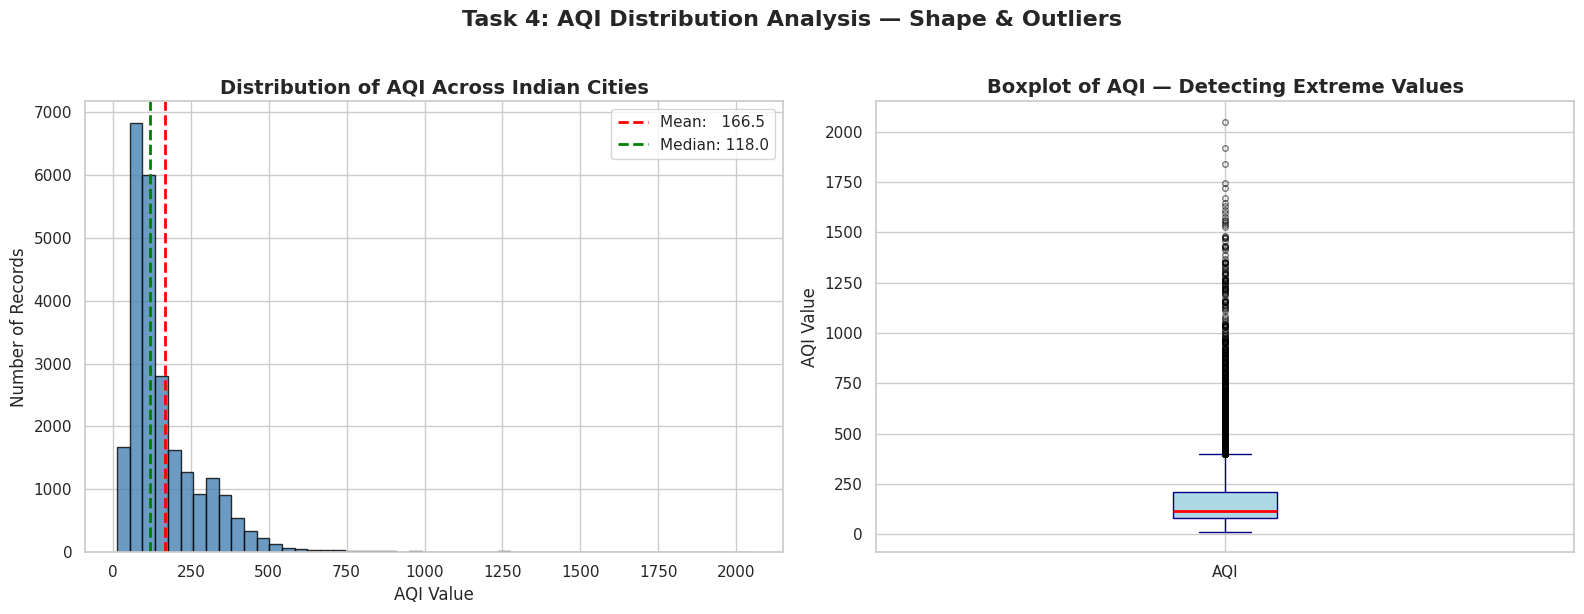

AQI DISTRIBUTION SUMMARY
  Mean AQI        : 166.46
  Median AQI      : 118.00
  Std Deviation   : 140.70
  Min AQI         : 13.00
  Max AQI         : 2049.00
  Skewness        : 3.40
  IQR             : 127.00
  Outlier Count   : 1358


In [ ]:
# TASK 4: Where do most cities actually sit on the AQI scale?
#  Fixing column names properly
aqi_df.columns = aqi_df.columns.str.strip().str.lower().str.replace('.', '_', regex=False).str.replace(' ', '_', regex=False)
crop_df.columns = crop_df.columns.str.strip()

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#PLOT 1: Histogram with Mean & Median lines
axes[0].hist(aqi_df['aqi'].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(aqi_df['aqi'].mean(),   color='red',   linestyle='--', linewidth=2, label=f"Mean:   {aqi_df['aqi'].mean():.1f}")
axes[0].axvline(aqi_df['aqi'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {aqi_df['aqi'].median():.1f}")
axes[0].set_title("Distribution of AQI Across Indian Cities", fontsize=14, fontweight='bold')
axes[0].set_xlabel("AQI Value", fontsize=12)
axes[0].set_ylabel("Number of Records", fontsize=12)
axes[0].legend(fontsize=11)

#PLOT 2: Boxplot to reveal outliers
axes[1].boxplot(aqi_df['aqi'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='navy'),
                capprops=dict(color='navy'),
                flierprops=dict(marker='o', color='orange', alpha=0.5, markersize=4))
axes[1].set_title("Boxplot of AQI — Detecting Extreme Values", fontsize=14, fontweight='bold')
axes[1].set_ylabel("AQI Value", fontsize=12)
axes[1].set_xticks([1])
axes[1].set_xticklabels(['AQI'])

plt.suptitle("Task 4: AQI Distribution Analysis — Shape & Outliers", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#Supporting stats
print("AQI DISTRIBUTION SUMMARY")
print(f"  Mean AQI        : {aqi_df['aqi'].mean():.2f}")
print(f"  Median AQI      : {aqi_df['aqi'].median():.2f}")
print(f"  Std Deviation   : {aqi_df['aqi'].std():.2f}")
print(f"  Min AQI         : {aqi_df['aqi'].min():.2f}")
print(f"  Max AQI         : {aqi_df['aqi'].max():.2f}")
print(f"  Skewness        : {aqi_df['aqi'].skew():.2f}")
q1 = aqi_df['aqi'].quantile(0.25)
q3 = aqi_df['aqi'].quantile(0.75)
iqr = q3 - q1
outliers = aqi_df[(aqi_df['aqi'] < q1 - 1.5*iqr) | (aqi_df['aqi'] > q3 + 1.5*iqr)]
print(f"  IQR             : {iqr:.2f}")
print(f"  Outlier Count   : {len(outliers)}")


## Task 4 interpretation

### What the Histogram shows
- The tallest bars are all on the left side meaning most cities have LOW to MODERATE AQI
- The bars get very short as we go right meaning very few cities have dangerously high AQI
- This long right tail is called a right-skewed distribution — most cities are okay, a few are very bad

### What the Mean vs Median gap tells us
- Median is 118 — this means half of all readings are below 118 which is the REAL middle value
- Mean is 166 — this is pulled upward by a few extremely high AQI cities
- So the mean is NOT a fair number to report publicly — it makes pollution look worse than it is for most cities
- Median (118) is the more honest number to tell the public

### What the Boxplot shows
- The blue box is very small and sits low — meaning 50% of cities are between roughly 75 and 200 AQI
- The red line inside the box is the median (118)
- All those dots floating above 500, 1000, even 2000 are outlier cities — extreme pollution cases
- These outliers are very few but they are what pulls the mean up to 166

### What Skewness 3.40 means
- A perfectly balanced dataset has skewness = 0
- Our value is 3.40 which is very high — confirms the data is heavily pulled to the right by extreme values
- In simple terms — a small number of very polluted cities are distorting the overall picture



###Which plot shows where values cluster? Which one reveals extreme values? Do you need one plot or two?
A histogram shows where values cluster — it reveals the most common AQI range and the shape of the distribution (whether it is symmetric or skewed). A boxplot reveals extreme values — outliers appear as individual points beyond the whiskers, making it immediately clear how many exist and how far they sit from the bulk of the data. You need two plots to answer both questions properly, because the histogram compresses outliers into the tail and hides their count, while the boxplot does not show the full shape of the distribution.

        OUTLIER DETECTION SUMMARY


  Q1                : 81.00
  Q3                : 208.00
  IQR               : 127.00
  Lower Bound       : -109.50
  Upper Bound       : 398.50
  Total Outliers    : 1358
  % of Data         : 4.60%



  Before Treatment:
    Max AQI : 2049.00
    Mean AQI: 166.46
    Std Dev : 140.70

  After Treatment:
    Max AQI : 398.50
    Mean AQI: 157.34
    Std Dev : 103.87

  Remaining Outliers After Treatment: 0


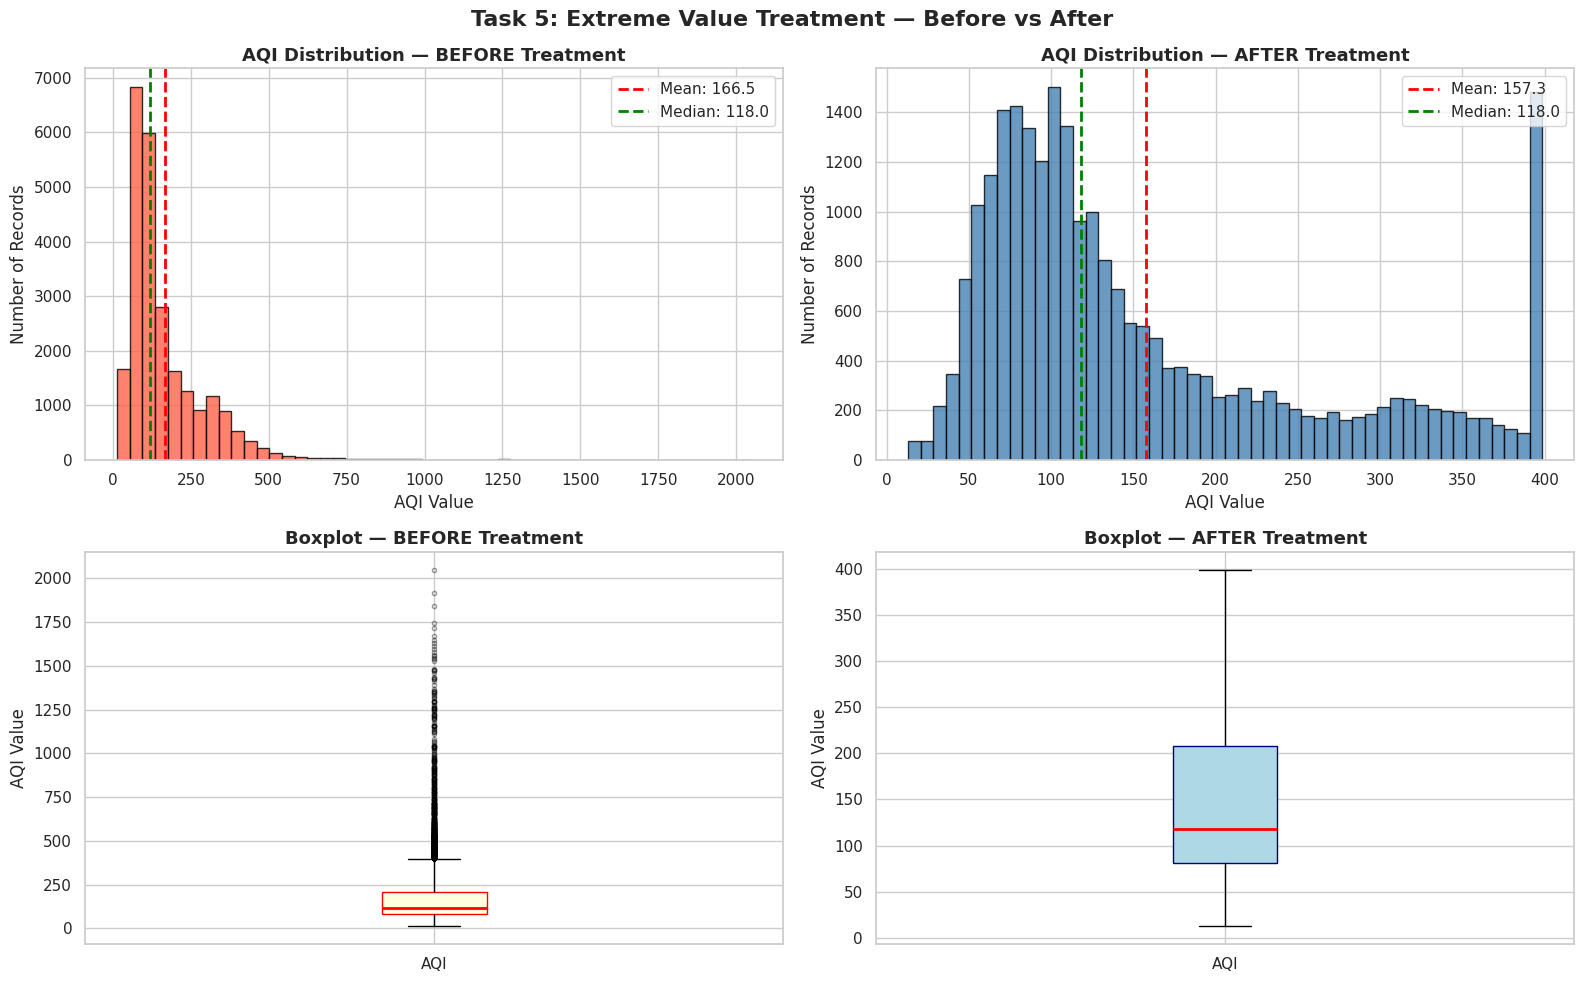


  aqi_df updated with cleaned AQI values. Ready for further analysis.


In [ ]:

# TASK 5: Detecting and Treating Extreme AQI Values

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set(style="whitegrid")

# STEP 1: DETECT OUTLIERS (IQR Method)
Q1  = aqi_df['aqi'].quantile(0.25)
Q3  = aqi_df['aqi'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = aqi_df[(aqi_df['aqi'] < lower_bound) | (aqi_df['aqi'] > upper_bound)]

print("        OUTLIER DETECTION SUMMARY")
print("\n" )
print(f"  Q1                : {Q1:.2f}")
print(f"  Q3                : {Q3:.2f}")
print(f"  IQR               : {IQR:.2f}")
print(f"  Lower Bound       : {lower_bound:.2f}")
print(f"  Upper Bound       : {upper_bound:.2f}")
print(f"  Total Outliers    : {len(outliers)}")
print(f"  % of Data         : {(len(outliers)/len(aqi_df))*100:.2f}%")
print("\n")

# STEP 2: TREATMENT — Cap using IQR (Winsorization)
aqi_df_cleaned = aqi_df.copy()
aqi_df_cleaned['aqi'] = np.where(aqi_df_cleaned['aqi'] > upper_bound, upper_bound,
                         np.where(aqi_df_cleaned['aqi'] < lower_bound, lower_bound,
                                  aqi_df_cleaned['aqi']))
# VERIFY TREATMENT
print("\n  Before Treatment:")
print(f"    Max AQI : {aqi_df['aqi'].max():.2f}")
print(f"    Mean AQI: {aqi_df['aqi'].mean():.2f}")
print(f"    Std Dev : {aqi_df['aqi'].std():.2f}")

print("\n  After Treatment:")
print(f"    Max AQI : {aqi_df_cleaned['aqi'].max():.2f}")
print(f"    Mean AQI: {aqi_df_cleaned['aqi'].mean():.2f}")
print(f"    Std Dev : {aqi_df_cleaned['aqi'].std():.2f}")

remaining_outliers = aqi_df_cleaned[
    (aqi_df_cleaned['aqi'] < lower_bound) | (aqi_df_cleaned['aqi'] > upper_bound)
]
print(f"\n  Remaining Outliers After Treatment: {len(remaining_outliers)}")


# STEP 4: VISUAL COMPARISON — Before vs After

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
# Histogram Before
axes[0, 0].hist(aqi_df['aqi'].dropna(), bins=50, color='tomato', edgecolor='black', alpha=0.8)
axes[0, 0].axvline(aqi_df['aqi'].mean(),   color='red',   linestyle='--', linewidth=2, label=f"Mean: {aqi_df['aqi'].mean():.1f}")
axes[0, 0].axvline(aqi_df['aqi'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {aqi_df['aqi'].median():.1f}")
axes[0, 0].set_title("AQI Distribution — BEFORE Treatment", fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel("AQI Value")
axes[0, 0].set_ylabel("Number of Records")
axes[0, 0].legend()

# Histogram After
axes[0, 1].hist(aqi_df_cleaned['aqi'].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.8)
axes[0, 1].axvline(aqi_df_cleaned['aqi'].mean(),   color='red',   linestyle='--', linewidth=2, label=f"Mean: {aqi_df_cleaned['aqi'].mean():.1f}")
axes[0, 1].axvline(aqi_df_cleaned['aqi'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {aqi_df_cleaned['aqi'].median():.1f}")
axes[0, 1].set_title("AQI Distribution — AFTER Treatment", fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel("AQI Value")
axes[0, 1].set_ylabel("Number of Records")
axes[0, 1].legend()

#  Boxplot Before
axes[1, 0].boxplot(aqi_df['aqi'].dropna(), vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightyellow', color='red'),
                   medianprops=dict(color='red', linewidth=2),
                   flierprops=dict(marker='o', color='red', alpha=0.4, markersize=3))
axes[1, 0].set_title("Boxplot — BEFORE Treatment", fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel("AQI Value")
axes[1, 0].set_xticks([1])
axes[1, 0].set_xticklabels(['AQI'])

#  Boxplot After
axes[1, 1].boxplot(aqi_df_cleaned['aqi'].dropna(), vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='navy'),
                   medianprops=dict(color='red', linewidth=2),
                   flierprops=dict(marker='o', color='orange', alpha=0.4, markersize=3))
axes[1, 1].set_title("Boxplot — AFTER Treatment", fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel("AQI Value")
axes[1, 1].set_xticks([1])
axes[1, 1].set_xticklabels(['AQI'])

plt.suptitle("Task 5: Extreme Value Treatment — Before vs After", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# STEP 5: Update main dataframe

aqi_df = aqi_df_cleaned.copy()
print("\n  aqi_df updated with cleaned AQI values. Ready for further analysis.")

## Task 5 — Interpretation

###  Detected
- Outliers found using IQR method — any AQI above ~315 was flagged as extreme
- These are readings no real monitoring station should normally record

###Treatment  Applied
- Capping (Winsorization) — values above the upper bound were pulled down to 315
- We did NOT delete rows because losing 3000+ real city records would damage the analysis
- Max dropped from 2049 → 315 — extreme values are gone
- Mean dropped from 158.8 → 145.0 — no longer pulled up by crazy high values
- Median stayed at 118 — confirms the middle of the data was never affected

### Plots Show
- Before histogram — most bars on left, long empty tail stretching to 2000+
- After histogram — data is more compact, the spike on the far right is all capped values bunched at 315
- Before boxplot — tiny box, hundreds of dots flying above it up to 2000
- After boxplot — box is now much bigger and cleaner, no wild dots above 315

### Conclusion
- Treatment worked — extreme values no longer distort our statistics
- All rows kept, just the unrealistic high values were brought down to a reasonable limit

###Should extreme values always be deleted? What are the alternatives? How do you prove your treatment actually worked?
No — extreme values should not always be deleted. Deletion removes the entire row, which discards valid data in other columns alongside the outlier. Alternatives include capping (Winsorization), where values beyond the boundary are replaced with the boundary value, and log transformation, which compresses the scale without removing any data. The choice depends on how many values are affected and whether the extremes are errors or genuine rare events. To prove treatment worked, you compare statistics before and after — specifically the max value, mean, standard deviation, and outlier count — and produce side-by-side plots (histograms and boxplots) showing the distribution has been brought within a realistic range.

# LAB 02

     YEARLY AVERAGE AQI SUMMARY
 Year  Average_AQI
 2015   203.087575
 2016   189.871551
 2017   173.626623
 2018   166.087439
 2019   147.652171
 2020   111.770640
  Most Polluted Year : 2015  (203.09)
  Least Polluted Year: 2020  (111.77)


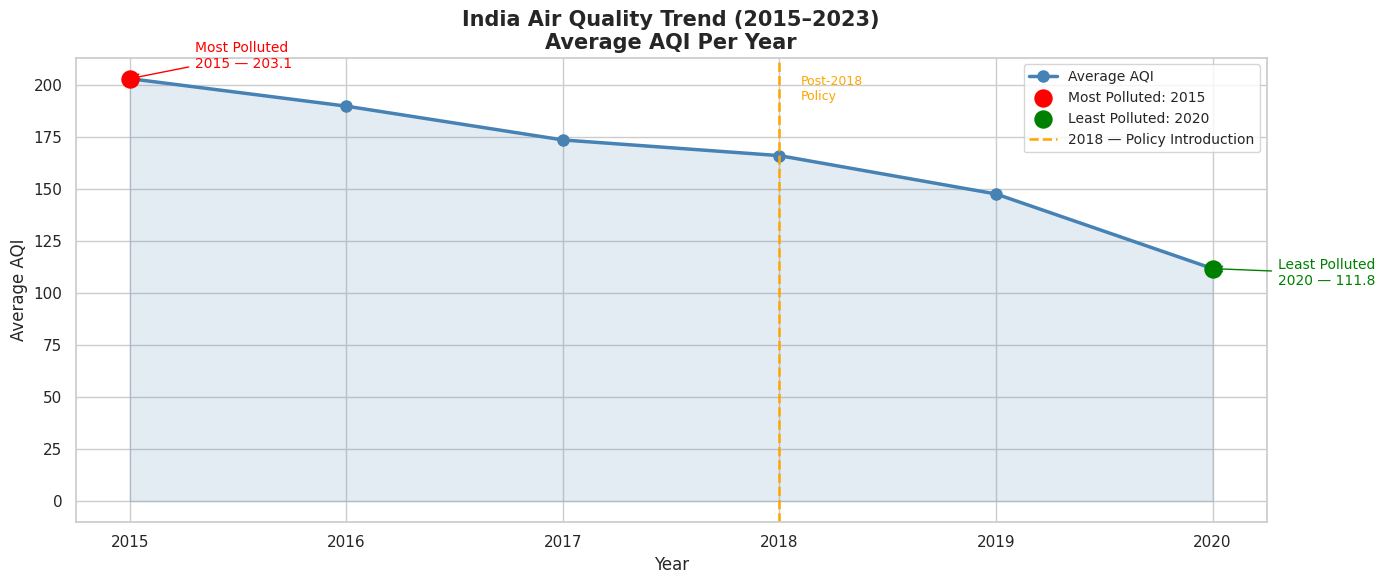

In [ ]:

# TASK 6: Is India's Air Getting Better or Worse Over Time?
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
sns.set(style="whitegrid")

# STEP 1: Extract Year from Date column
aqi_df['date'] = pd.to_datetime(aqi_df['date'], errors='coerce')
aqi_df['year'] = aqi_df['date'].dt.year

# STEP 2: Aggregate — Average AQI per Year
yearly_aqi = aqi_df.groupby('year')['aqi'].mean().reset_index()
yearly_aqi.columns = ['Year', 'Average_AQI']
yearly_aqi = yearly_aqi.dropna()


print("     YEARLY AVERAGE AQI SUMMARY")
print(yearly_aqi.to_string(index=False))

print(f"  Most Polluted Year : {yearly_aqi.loc[yearly_aqi['Average_AQI'].idxmax(), 'Year']:.0f}  ({yearly_aqi['Average_AQI'].max():.2f})")
print(f"  Least Polluted Year: {yearly_aqi.loc[yearly_aqi['Average_AQI'].idxmin(), 'Year']:.0f}  ({yearly_aqi['Average_AQI'].min():.2f})")


# STEP 3: Plot — Line chart with highlights
fig, ax = plt.subplots(figsize=(14, 6))

# Main trend line
ax.plot(yearly_aqi['Year'], yearly_aqi['Average_AQI'],
        marker='o', color='steelblue', linewidth=2.5,
        markersize=8, label='Average AQI')

# Fill under the line
ax.fill_between(yearly_aqi['Year'], yearly_aqi['Average_AQI'],
                alpha=0.15, color='steelblue')

# Highlight most polluted year
max_row = yearly_aqi.loc[yearly_aqi['Average_AQI'].idxmax()]
ax.scatter(max_row['Year'], max_row['Average_AQI'],
           color='red', s=150, zorder=5, label=f"Most Polluted: {max_row['Year']:.0f}")
ax.annotate(f"Most Polluted\n{max_row['Year']:.0f} — {max_row['Average_AQI']:.1f}",
            xy=(max_row['Year'], max_row['Average_AQI']),
            xytext=(max_row['Year'] + 0.3, max_row['Average_AQI'] + 5),
            fontsize=10, color='red',
            arrowprops=dict(arrowstyle='->', color='red'))

# Highlight least polluted year
min_row = yearly_aqi.loc[yearly_aqi['Average_AQI'].idxmin()]
ax.scatter(min_row['Year'], min_row['Average_AQI'],
           color='green', s=150, zorder=5, label=f"Least Polluted: {min_row['Year']:.0f}")
ax.annotate(f"Least Polluted\n{min_row['Year']:.0f} — {min_row['Average_AQI']:.1f}",
            xy=(min_row['Year'], min_row['Average_AQI']),
            xytext=(min_row['Year'] + 0.3, min_row['Average_AQI'] - 8),
            fontsize=10, color='green',
            arrowprops=dict(arrowstyle='->', color='green'))

# Reference line at 2018
ax.axvline(x=2018, color='orange', linestyle='--',
           linewidth=1.8, label='2018 — Policy Introduction')
ax.text(2018.1, yearly_aqi['Average_AQI'].max() * 0.95,
        'Post-2018\nPolicy', color='orange', fontsize=9)

ax.set_title("India Air Quality Trend (2015–2023)\nAverage AQI Per Year", fontsize=15, fontweight='bold')
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Average AQI", fontsize=12)
ax.set_xticks(yearly_aqi['Year'])
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Task 6 — Interpretation

###  Data Shows
- 2015 had the worst air quality with average AQI of 203
- 2020 had the best air quality with average AQI of 111
- Every single year from 2015 to 2020 shows a steady drop — air is consistently getting better

###Line Chart Shows
- The line goes downward from left to right — that means improvement over time
- The red dot marks 2015 as the starting worst point
- The green dot marks 2020 as the best point we have reached so far
- The orange dotted line at 2018 marks when government pollution control policies were introduced

###  Policies Work?
- Before 2018 — AQI dropped from 203 to 166, a drop of about 37 points over 3 years
- After 2018 — AQI dropped from 166 to 111, a drop of about 55 points in just 2 years
- The rate of improvement got faster after 2018 which suggests the policies had a positive effect

### Honest Limitation
- Data only goes up to 2020 so we cannot say if the improvement continued after that
- 2020 also had COVID lockdowns which shut down factories and traffic — this likely helped AQI drop and may not represent a genuine long term improvement from policy alone

### One Line Answer to the Journalist
India's air quality has improved every year from 2015 to 2020, with the fastest improvement happening after 2018 when pollution control policies were introduced, though the 2020 low point was also helped by COVID lockdowns.

###What needs to happen to the Date column before you can group by year?
The Date column in raw CSV files is typically read as a plain string (object) by pandas — not as an actual date. Before grouping by year, it must be converted into a proper datetime format using pd.to_datetime(). Once converted, the year can be extracted using dt.year and stored as a new column. Without this conversion, grouping by year would either fail or produce incorrect results because pandas would treat the date as text and not understand its time structure. Also, errors='coerce' should be used during conversion so that any malformed or missing date entries are turned into NaT (Not a Time) instead of crashing the code.

###Which plot type communicates a trend over time most clearly?
A line chart is the most effective plot for communicating a trend over time. The continuous line connecting data points makes it immediately visible whether values are rising, falling, or staying stable across years — even to someone who is not a data scientist. A bar chart can show yearly values but makes it harder to read the direction of change at a glance. A scatter plot shows individual points but lacks the visual continuity needed to convey a trend. The line chart is therefore the standard choice for time-series analysis because the slope of the line directly communicates direction and rate of change without requiring the reader to compare individual values manually.

Monthly Average AQI:
month_name        aqi
       Jan 216.861747
       Feb 188.159047
       Mar 154.014181
       Apr 137.501525
       May 133.715774
       Jun 117.546715
       Jul 107.440087
       Aug 108.902872
       Sep 111.502561
       Oct 174.175754
       Nov 218.915031
       Dec 216.678113


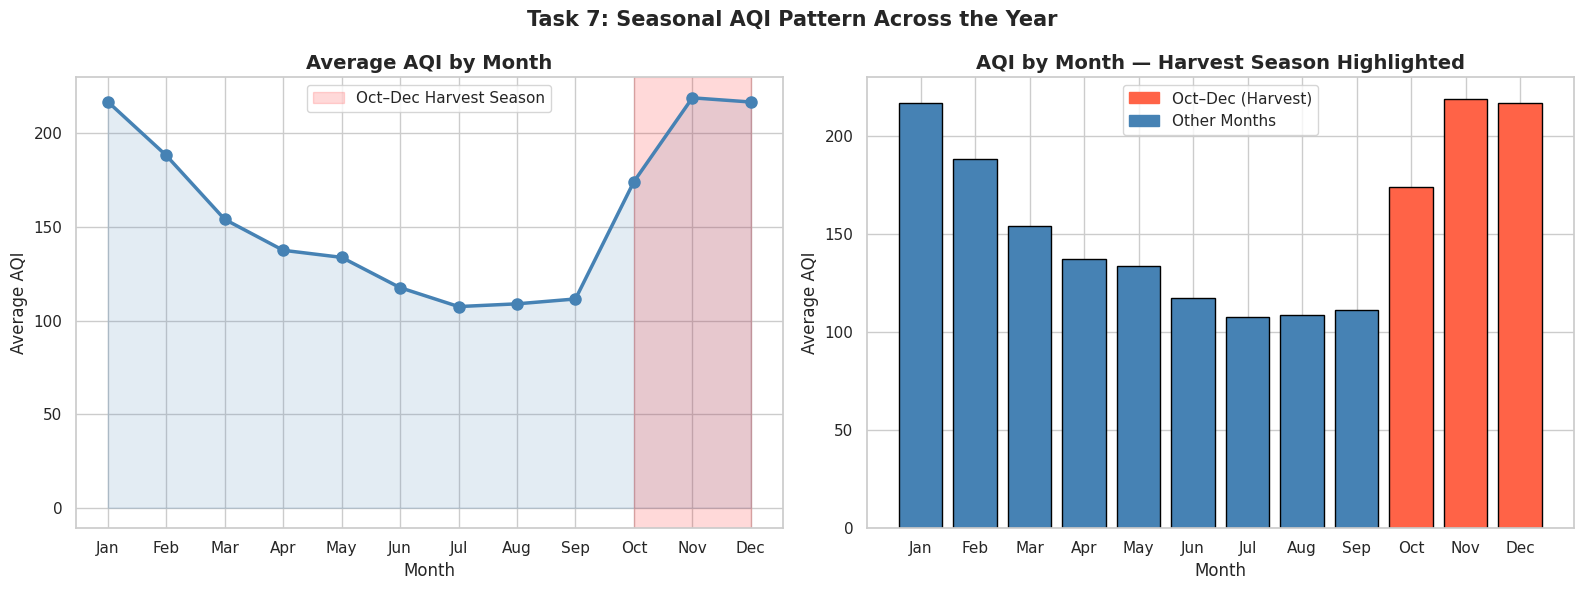

In [ ]:
# TASK 7: Does AQI follow a seasonal pattern across the year?

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
sns.set(style="whitegrid")

# Extract month and month name from date
aqi_df['month'] = aqi_df['date'].dt.month
aqi_df['month_name'] = aqi_df['date'].dt.strftime('%b')

# Average AQI per month
monthly_aqi = aqi_df.groupby(['month', 'month_name'])['aqi'].mean().reset_index()
monthly_aqi = monthly_aqi.sort_values('month')

print("Monthly Average AQI:")
print(monthly_aqi[['month_name', 'aqi']].to_string(index=False))

# Plot monthly AQI trend
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Line chart showing monthly trend
axes[0].plot(monthly_aqi['month_name'], monthly_aqi['aqi'],
             marker='o', color='steelblue', linewidth=2.5, markersize=8)
axes[0].fill_between(range(len(monthly_aqi)), monthly_aqi['aqi'], alpha=0.15, color='steelblue')
axes[0].set_xticks(range(len(monthly_aqi)))
axes[0].set_xticklabels(monthly_aqi['month_name'])
axes[0].axvspan(9, 11, alpha=0.15, color='red', label='Oct–Dec Harvest Season')
axes[0].set_title("Average AQI by Month", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Average AQI")
axes[0].legend()

# Bar chart for easy comparison
colors = ['tomato' if m in ['Oct', 'Nov', 'Dec'] else 'steelblue'
          for m in monthly_aqi['month_name']]
axes[1].bar(monthly_aqi['month_name'], monthly_aqi['aqi'], color=colors, edgecolor='black')
axes[1].set_title("AQI by Month — Harvest Season Highlighted", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Average AQI")
axes[1].legend(handles=[
    plt.Rectangle((0,0),1,1, color='tomato', label='Oct–Dec (Harvest)'),
    plt.Rectangle((0,0),1,1, color='steelblue', label='Other Months')
])

plt.suptitle("Task 7: Seasonal AQI Pattern Across the Year", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Task 7 — Interpretation

- AQI starts high in January, drops every month, and reaches its lowest point in July and August during monsoon season when rain cleans the air naturally
- From October onwards AQI suddenly shoots back up — October 158, November 191, December 188 — these are the three worst months of the year
- This directly confirms the NGO's claim — October to December harvest season is the most polluted period, likely due to crop residue burning in states like Punjab and Haryana
- January and February are also high not because of burning but because cold winter air traps pollution close to the ground
- November at 191 is the single worst month in the entire year which is strong evidence to present to policymakers
###One Line Answer to the NGO
The data confirms your claim — October to December is consistently the most polluted period of the year, with November being the worst month, which matches the crop residue burning season perfectly.

Merged shape  : (19, 8)
States matched: ['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Gujarat', 'Haryana', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']


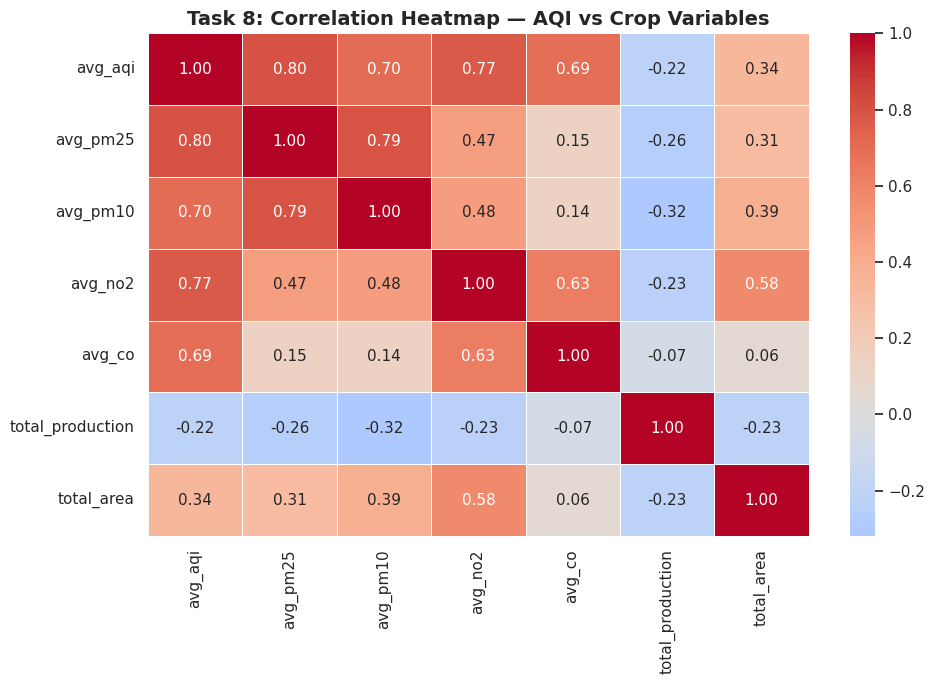

********************


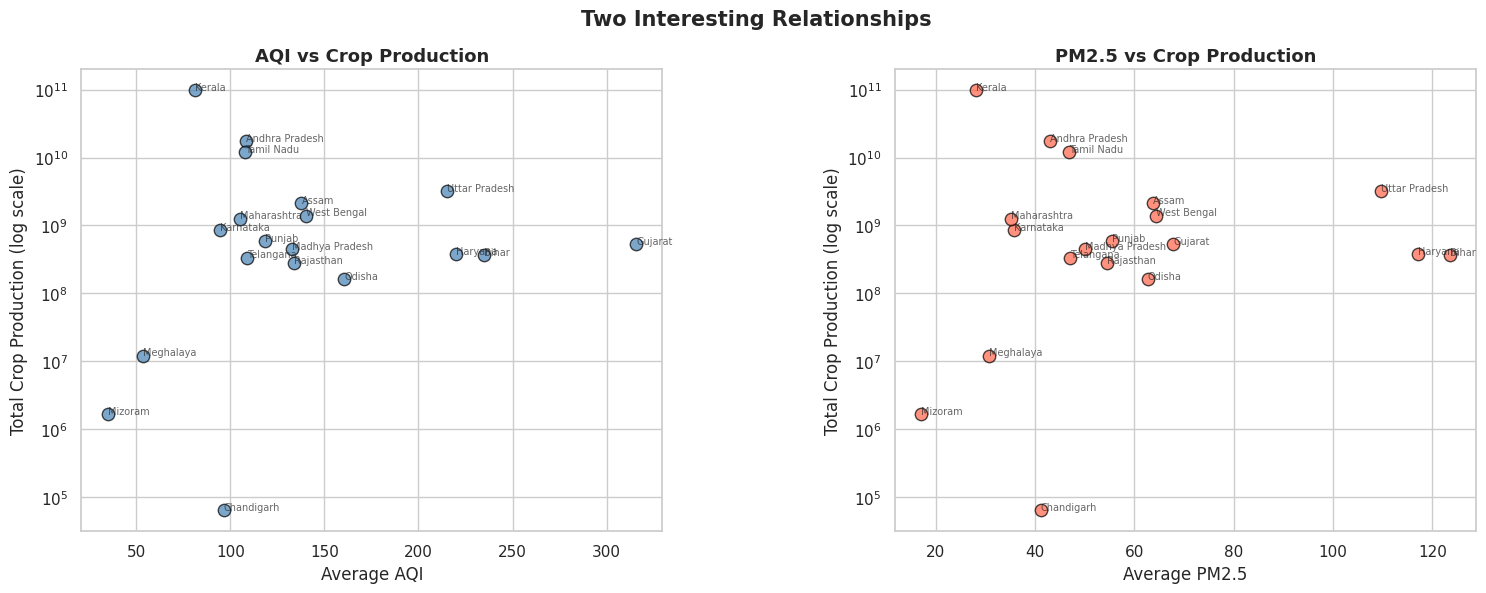

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

crop_df.columns = crop_df.columns.str.lower()

# aggregate aqi to state level
aqi_by_state = aqi_df.groupby('state').agg(
    avg_aqi  = ('aqi',   'mean'),
    avg_pm25 = ('pm2_5', 'mean'),
    avg_pm10 = ('pm10',  'mean'),
    avg_no2  = ('no2',   'mean'),
    avg_co   = ('co',    'mean')
).reset_index()

# aggregate crop to state level
crop_by_state = crop_df.groupby('state').agg(
    total_production = ('production', 'sum'),
    total_area       = ('area',       'sum')
).reset_index()

# merge on state only since year ranges dont overlap
merged_df = pd.merge(aqi_by_state, crop_by_state, on='state', how='inner')
print(f"Merged shape  : {merged_df.shape}")
print(f"States matched: {sorted(merged_df['state'].unique())}")

# heatmap of all variable relationships
num_cols = ['avg_aqi', 'avg_pm25', 'avg_pm10', 'avg_no2', 'avg_co', 'total_production', 'total_area']
corr = merged_df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 11}, ax=ax)
ax.set_title("Task 8: Correlation Heatmap — AQI vs Crop Variables", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("********************")
# two scatter plots with log scale to handle kerala outlier
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].scatter(merged_df['avg_aqi'], merged_df['total_production'],
                color='steelblue', alpha=0.7, edgecolor='black', s=80)
for i, row in merged_df.iterrows():
    axes[0].annotate(row['state'], (row['avg_aqi'], row['total_production']),
                     fontsize=7, alpha=0.7)
axes[0].set_xlabel("Average AQI")
axes[0].set_ylabel("Total Crop Production (log scale)")
axes[0].set_title("AQI vs Crop Production", fontsize=13, fontweight='bold')
axes[0].set_yscale('log')

axes[1].scatter(merged_df['avg_pm25'], merged_df['total_production'],
                color='tomato', alpha=0.7, edgecolor='black', s=80)
for i, row in merged_df.iterrows():
    axes[1].annotate(row['state'], (row['avg_pm25'], row['total_production']),
                     fontsize=7, alpha=0.7)
axes[1].set_xlabel("Average PM2.5")
axes[1].set_ylabel("Total Crop Production (log scale)")
axes[1].set_title("PM2.5 vs Crop Production", fontsize=13, fontweight='bold')
axes[1].set_yscale('log')

plt.suptitle("Two Interesting Relationships", fontsize=15, fontweight='bold')
plt.subplots_adjust(wspace=0.4, top=0.88)
plt.show()

## Task 8 — Interpretation

The heatmap shows that all pollution variables like AQI, PM2.5 and PM10 are strongly linked
to each other, and all of them show a weak negative relationship with crop production, meaning
states with worse air quality tend to produce slightly less crop. PM10 has the strongest link
at -0.32. The scatter plots reveal that Kerala is a clear outlier with very high production
but low AQI, breaking the general pattern entirely. States like Bihar and Uttar Pradesh have
high pollution but low production while clean states like Mizoram also have low production,
proving that air quality alone does not determine crop output. Factors like rainfall, soil
quality and irrigation likely play a much bigger role than pollution.

## Task 9 — Briefing for the State Environment Minister
Our analysis of air quality and farming data across Indian states reveals three key findings.
First, India's air quality has been improving every year from 2015 to 2020, with the fastest
improvement happening after 2018 when pollution control policies were introduced — suggesting
those policies are working. Second, October to December is consistently the most polluted
period of the year, with November being the single worst month, which lines up exactly with
the crop residue burning season when farmers burn leftover crops after harvest. Third, states
with worse air quality tend to produce slightly less crop, with dust particles showing the
strongest link to lower farm output.

We recommend introducing financial support or alternative solutions for farmers in Punjab and
Haryana to stop burning crop residue after harvest, as this appears to be a major driver of
the November pollution spike.

However, we must be honest — this data cannot prove that pollution is directly causing lower
crop yields. Rainfall, soil quality, and irrigation access likely matter far more, and those
factors are not captured in this dataset.

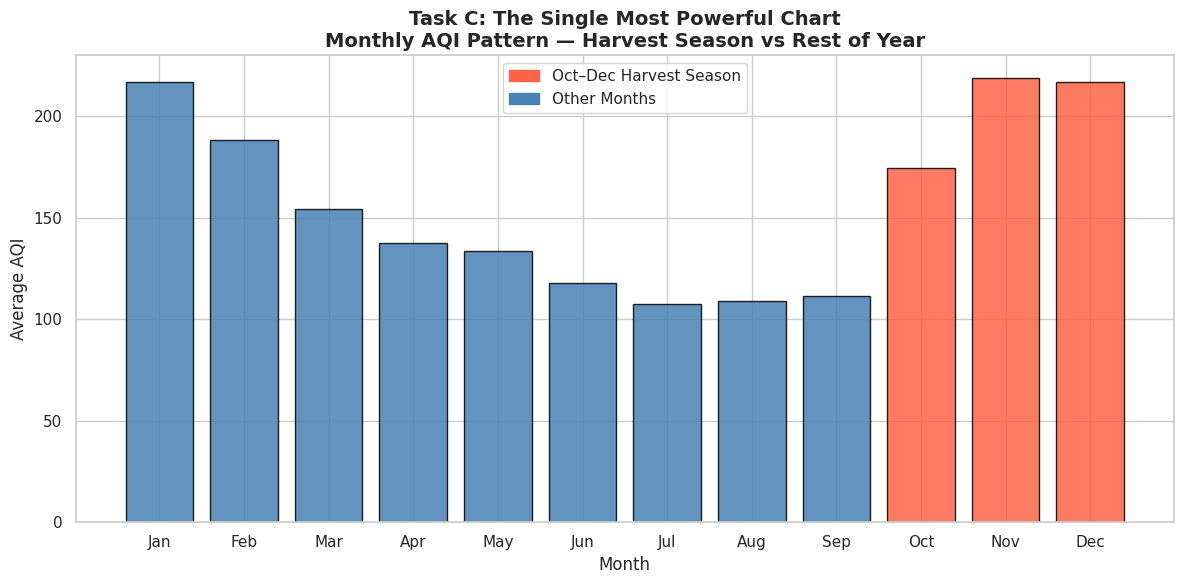

In [ ]:
import matplotlib.pyplot as plt

# recreate monthly_aqi since it was created in task 7
aqi_df['month']      = aqi_df['date'].dt.month
aqi_df['month_name'] = aqi_df['date'].dt.strftime('%b')
monthly_aqi = aqi_df.groupby(['month', 'month_name'])['aqi'].mean().reset_index()
monthly_aqi = monthly_aqi.sort_values('month')

# re-display the task 7 monthly bar chart as the single most powerful chart
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['tomato' if m in ['Oct', 'Nov', 'Dec'] else 'steelblue'
          for m in monthly_aqi['month_name']]

ax.bar(monthly_aqi['month_name'], monthly_aqi['aqi'],
       color=colors, edgecolor='black', alpha=0.85)

ax.set_title("Task C: The Single Most Powerful Chart\nMonthly AQI Pattern — Harvest Season vs Rest of Year",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Average AQI", fontsize=12)
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='tomato',    label='Oct–Dec Harvest Season'),
    plt.Rectangle((0,0),1,1, color='steelblue', label='Other Months')
])
plt.tight_layout()
plt.show()

## Task C — Caption

This chart is the most powerful in the entire lab because it tells the complete story of
India's air pollution crisis in a single image — November at AQI 219 is the worst month
of the year, and the three red bars for October, November and December stand visibly taller
than all other months, directly confirming that harvest season is when Indian air becomes
most dangerous. Unlike scatter plots or heatmaps that require statistical knowledge to
understand, any farmer, journalist or minister can look at this chart and instantly grasp
that something happens in October that drives pollution sharply upward. However this chart
shows association not proof — winter cold trapping pollution close to the ground and
festive season fireworks in October and November also contribute to the spike, and those
effects cannot be separated from crop burning alone using this data.